<a href="https://colab.research.google.com/github/Sancheuz123/KSVD/blob/main/%D0%9B%D0%A0_3_%D0%93%D0%B0%D0%B9%D0%B2%D0%BE%D1%80%D0%BE%D0%BD%D1%81%D1%8C%D0%BA%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving spotify-2023.csv to spotify-2023.csv


In [ ]:
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    object 
 1   artist(s)_name        953 non-null    object 
 2   artist_count          953 non-null    int64  
 3   released_year         953 non-null    int64  
 4   released_month        953 non-null    int64  
 5   released_day          953 non-null    int64  
 6   in_spotify_playlists  953 non-null    int64  
 7   in_spotify_charts     953 non-null    int64  
 8   streams               952 non-null    float64
 9   in_apple_playlists    953 non-null    int64  
 10  in_apple_charts       953 non-null    int64  
 11  in_deezer_playlists   953 non-null    object 
 12  in_deezer_charts      953 non-null    int64  
 13  in_shazam_charts      903 non-null    object 
 14  bpm                   953 non-null    int64  
 15  key                   8

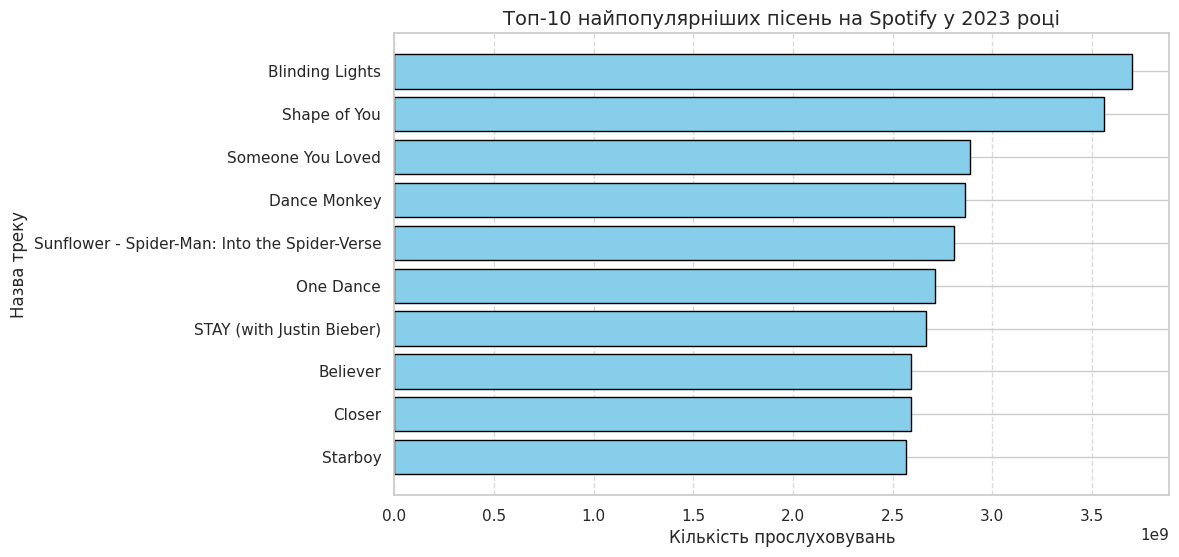

In [ ]:
plt.figure(figsize=(10, 6))

top_10_songs = df.nlargest(10, 'streams')

plt.barh(top_10_songs['track_name'], top_10_songs['streams'], color='skyblue', edgecolor='black')

plt.gca().invert_yaxis()

plt.title('Топ-10 найпопулярніших пісень на Spotify у 2023 році', fontsize=14)
plt.xlabel('Кількість прослуховувань', fontsize=12)
plt.ylabel('Назва треку', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

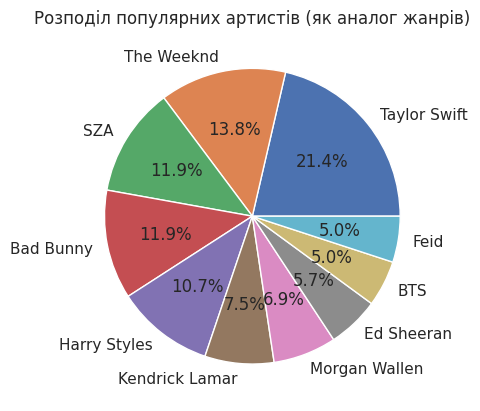

In [ ]:
top_genres = df['artist(s)_name'].value_counts().head(10)

plt.figure()
plt.pie(top_genres, labels=top_genres.index, autopct='%1.1f%%')
plt.title('Розподіл популярних артистів (як аналог жанрів)')
plt.show()

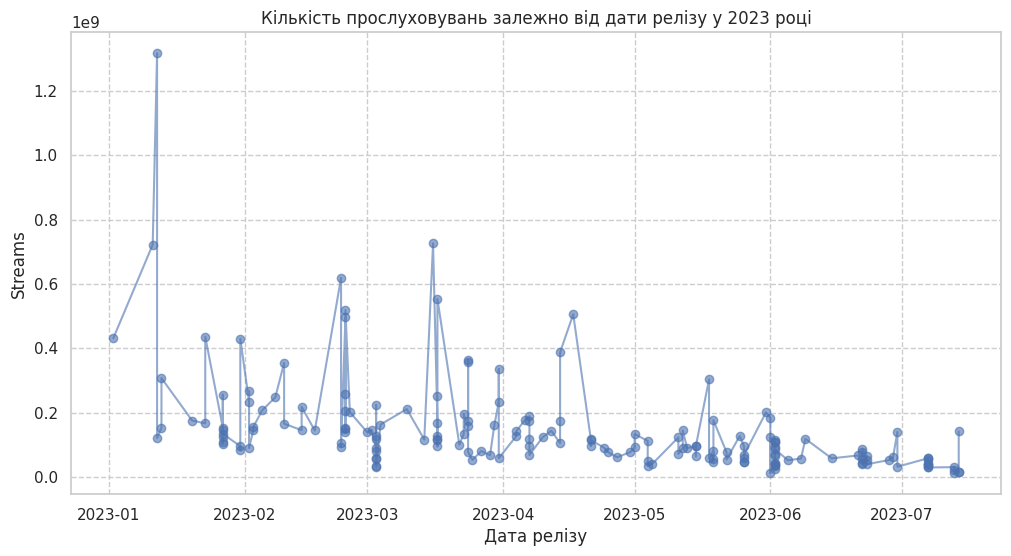

In [ ]:
df_2023 = df[df['released_year'] == 2023].copy()
df_2023['release_date'] = pd.to_datetime(df_2023[['released_year', 'released_month', 'released_day']].rename(
    columns={'released_year': 'year', 'released_month': 'month', 'released_day': 'day'}))

plt.figure(figsize=(12, 6))
df_sorted = df_2023.sort_values('release_date')
plt.plot(df_sorted['release_date'], df_sorted['streams'], marker='o', linestyle='-', alpha=0.6)
plt.title('Кількість прослуховувань залежно від дати релізу у 2023 році')
plt.xlabel('Дата релізу')
plt.ylabel('Streams')
plt.grid(True, linestyle='--')
plt.show()

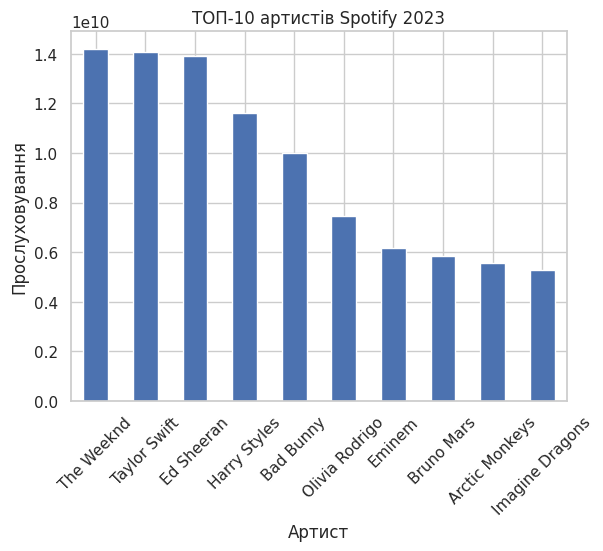

In [ ]:
top_artists = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_artists.plot(kind='bar')
plt.xlabel('Артист')
plt.ylabel('Прослуховування')
plt.title('ТОП-10 артистів Spotify 2023')
plt.xticks(rotation=45)
plt.show()

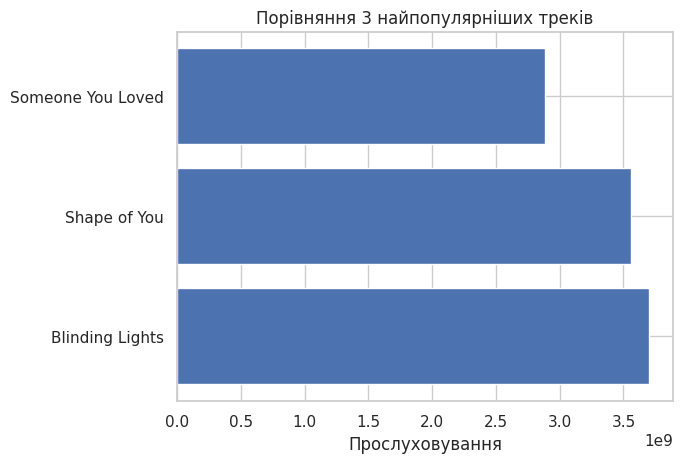

In [ ]:
top3 = df.sort_values(by='streams', ascending=False).head(3)

plt.figure()
plt.barh(top3['track_name'], top3['streams'])
plt.xlabel('Прослуховування')
plt.title('Порівняння 3 найпопулярніших треків')
plt.show()